# LiL-Q Interactive Demo

This notebook demonstrates the **Linear-in-Learnables Quasilinearized (LiL-Q)** solver
framework on several benchmark PDE problems from the manuscript.

**Problems covered:**
1. **Bratu equation** — scalar nonlinear elliptic PDE
2. **Kovasznay flow** — steady 2D incompressible Navier-Stokes
3. **Linear elasticity** — 2D plane-strain (linear PDE, single QR solve)
4. **Burgers equation** — 1D+time nonlinear parabolic PDE

Each demo configures the problem, runs the solver, and visualises the results.

In [1]:
import sys, os, time
import numpy as np
import matplotlib.pyplot as plt

# Add project root to path
sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'examples' else os.getcwd())

import lilq
from lilq.utils import set_seed, DEVICE

print(f'Device: {DEVICE}')
set_seed(42)

c:\Users\awoji\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Device: cuda


---
## 1. Bratu Equation

$$u_{xx} + u_{yy} + \lambda e^u = 0 \quad \text{on } [0,1]^2, \quad u|_{\partial\Omega} = 0$$

Highly nonlinear elliptic PDE. LiL-Q applies Bellman-Kalaba quasilinearisation to reduce
each iteration to a weighted linear least-squares problem solved via QR factorisation.

In [2]:
from problems.bratu import BratuConfig, BratuOptConfig, run_lil_q, evaluate_lil_solution

# Fourier basis, R_tol matched to N=10 from the original experiments
bratu_cfg = BratuConfig(N_x=10, N_y=10, lambda_=6.2, basis_type='fourier', k_ratio=10)
bratu_opt = BratuOptConfig(max_quasi_iters_lil=25, R_tol=1e-4)

t0 = time.time()
bratu_basis, bratu_coeffs, bratu_metrics, bratu_summary = run_lil_q(bratu_cfg, bratu_opt, verbose=True)
bratu_time = time.time() - t0

print(f'\nConverged: {bratu_summary["converged"]}')
print(f'Final loss: {bratu_summary["final_loss"]:.4e}')
print(f'Iterations: {bratu_summary["total_iterations"]}')
print(f'Total time: {bratu_time:.3f}s')

  Pre-training LiL (least squares)...
  Pre-training complete. MSE: 0.000000e+00
  Initial loss: 3.844000e+01
  Converged at iteration 3

Converged: True
Final loss: 2.1611e-05
Iterations: 3
Total time: 0.060s


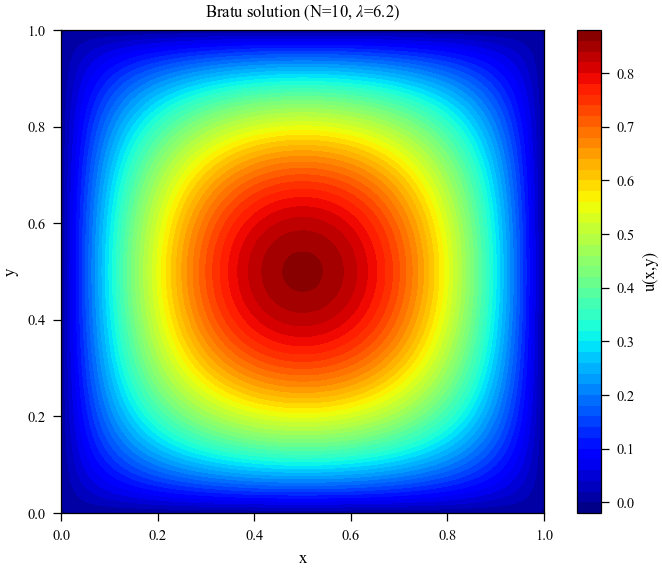

In [3]:
# Visualise Bratu solution field
# evaluate_lil_solution takes (basis, coeffs, config) and returns X, Y, U
X, Y, U = evaluate_lil_solution(bratu_basis, bratu_coeffs, bratu_cfg, n_eval=100)

fig, ax = plt.subplots(figsize=(5, 4))
cf = ax.contourf(X, Y, U, levels=50, cmap='jet')
plt.colorbar(cf, ax=ax, label='u(x,y)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(f'Bratu solution (N=10, $\\lambda$=6.2)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

---
## 2. Kovasznay Flow (Navier-Stokes)

Steady 2D incompressible Navier-Stokes with analytical solution at moderate Reynolds number.
Multi-field system: velocity $(u, v)$ and pressure $p$.

In [4]:
from problems.kovasznay import KovasznayConfig, solve_kovasznay, evaluate_all_fields

kov_cfg = KovasznayConfig(N_x=20, N_y=20, Re=40.0, basis_type='chebyshev',
                          k_ratio=4, max_iter=20, tol=1e-9)

t0 = time.time()
kov_result = solve_kovasznay(kov_cfg, verbose=True)
kov_time = time.time() - t0

print(f'\nOuter iters: {kov_result["n_outer_iters"]}')
print(f'Total time:  {kov_time:.3f}s')
print(f'rel L2 (u):  {kov_result["rel_l2_u"]:.3e}')
print(f'rel L2 (v):  {kov_result["rel_l2_v"]:.3e}')
print(f'rel L2 (p):  {kov_result["rel_l2_p"]:.3e}')

LiL-Q SOLVE: Kovasznay Flow
  Re=40.0, nu=0.0250, lam=-0.9637
  P_u=400, P_v=400, P_p=400, P_total=1200
  Iter   0: d_theta=1.000e+00  PDE=2.721e+00  cont=1.899e-08  QR=0.2818s
  Iter   1: d_theta=7.344e-01  PDE=1.501e-01  cont=2.578e-06  QR=0.2934s
  Iter   2: d_theta=8.224e-02  PDE=4.652e-05  cont=1.965e-08  QR=0.3364s
  Iter   3: d_theta=2.818e-03  PDE=1.665e-12  cont=6.513e-15  QR=0.2805s
  Iter   4: d_theta=3.165e-07  PDE=9.058e-16  cont=1.210e-16  QR=0.2912s
  Iter   5: d_theta=5.585e-14  PDE=9.058e-16  cont=1.210e-16  QR=0.2869s
  Converged at iteration 5.

  Total time: 5.3951s
  Final rel L2 errors:  u=7.330e-09  v=2.533e-08  p=5.295e-08

Outer iters: 6
Total time:  5.556s
rel L2 (u):  7.330e-09
rel L2 (v):  2.533e-08
rel L2 (p):  5.295e-08


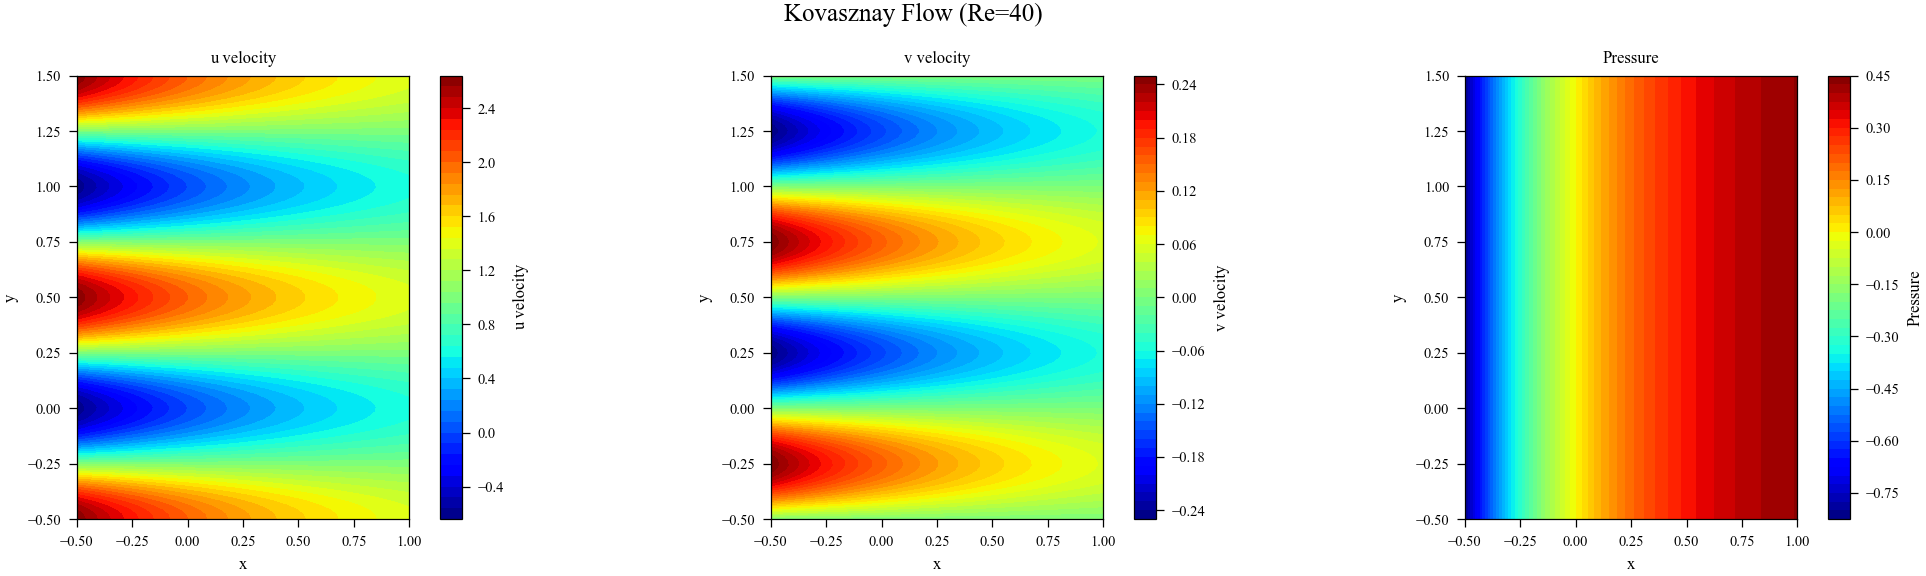

In [5]:
# Visualise Kovasznay velocity and pressure fields
# evaluate_all_fields returns (predicted_dict, exact_dict)
from problems.kovasznay import KovasznayPhysics
kov_phys = KovasznayPhysics(kov_cfg)
predicted, exact = evaluate_all_fields(kov_result, kov_phys, n_eval=100)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, key, label in zip(axes, ['u', 'v', 'p'], ['u velocity', 'v velocity', 'Pressure']):
    cf = ax.contourf(predicted['X'], predicted['Y'], predicted[key], levels=50, cmap='jet')
    plt.colorbar(cf, ax=ax, label=label)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(label)
    ax.set_aspect('equal')
plt.suptitle('Kovasznay Flow (Re=40)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 3. Linear Elasticity

2D plane-strain elasticity benchmark (Haghighat et al., CMAME 2021).
Since the PDE is linear, LiL-Q converges in a **single QR step**.

In [6]:
from problems.elasticity import ElasticityConfig, solve_elasticity, evaluate_all_fields as eval_elast

elast_cfg = ElasticityConfig(N_x=10, N_y=10, k_ratio=10)

t0 = time.time()
elast_result = solve_elasticity(elast_cfg, verbose=True)
elast_time = time.time() - t0

print(f'\nDOFs:        {elast_result["n_params"]}')
print(f'QR time:     {elast_result["solve_time_qr"]:.4f}s')
print(f'Total time:  {elast_time:.3f}s')
print(f'rel L2 (ux): {elast_result["rel_l2_ux"]:.3e}')
print(f'rel L2 (uy): {elast_result["rel_l2_uy"]:.3e}')

LiL DIRECT SOLVE: Linear Elasticity
  P_u=100, P_v=100, P_total=200
  BC mode: paper

  QR solve time: 0.0202s
  Total time: 0.1398s
  PDE residual MSE: 3.721143e-28
  Displacement errors (rel L2): u_x=7.147174e-16, u_y=9.318507e-16
  Stress errors (rel L2): sxx=4.324834e-16, syy=6.744075e-16, sxy=9.028693e-16

DOFs:        200
QR time:     0.0202s
Total time:  0.141s
rel L2 (ux): 7.147e-16
rel L2 (uy): 9.319e-16


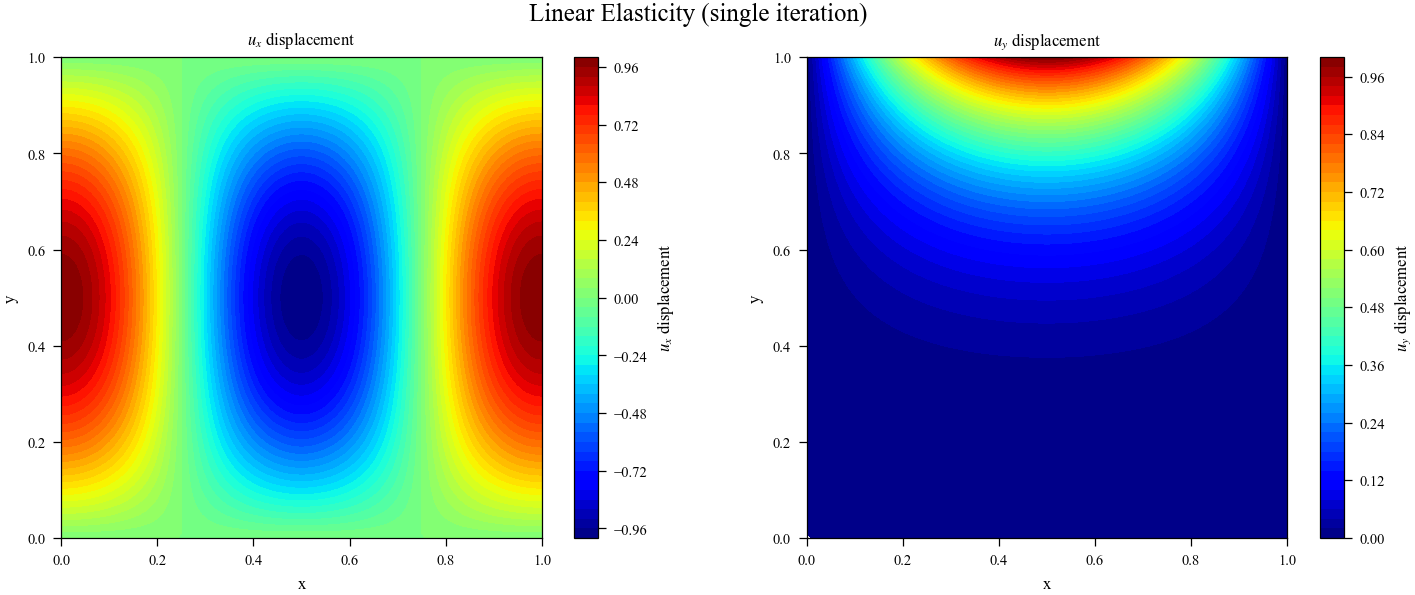

In [8]:
# Visualise displacement fields
# evaluate_all_fields returns (predicted_dict, exact_dict)
from problems.elasticity import ElasticityPhysics
elast_phys = ElasticityPhysics(elast_cfg)
epred, eexact = eval_elast(elast_result, elast_phys, n_eval=100)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, key, label in zip(axes, ['ux', 'uy'], ['$u_x$ displacement', '$u_y$ displacement']):
    cf = ax.contourf(epred['X'], epred['Y'], epred[key], levels=50, cmap='jet')
    plt.colorbar(cf, ax=ax, label=label)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(label)
    ax.set_aspect('equal')
plt.suptitle('Linear Elasticity (single iteration)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 4. Burgers Equation

$$u_t + u \cdot u_x - \nu u_{xx} = 0 \quad \text{on } [-1,1] \times [0,T]$$

Time-dependent nonlinear PDE with initial and boundary conditions.

In [9]:
from problems.burgers import BurgersConfig, BurgersOptConfig, run_lil_q as run_burgers_lilq, evaluate_lil_solution as eval_burgers

# Custom basis (Fourier sin x, Fourier both t), R_tol for N=10
burg_cfg = BurgersConfig(N_x=10, N_t=10, viscosity=0.1, basis_type='sin_fourier', k_ratio=10)
burg_opt = BurgersOptConfig(max_quasi_iters_lil=20, R_tol=1e-3)

t0 = time.time()
burg_basis, burg_coeffs, burg_metrics, burg_summary = run_burgers_lilq(burg_cfg, burg_opt, verbose=True)
burg_time = time.time() - t0

print(f'\nFinal loss:    {burg_summary["final_loss"]:.4e}')
print(f'Iterations:    {burg_summary["total_iterations"]}')
print(f'Converged:     {burg_summary["converged"]}')
print(f'Total time:    {burg_time:.3f}s')

  Pre-training LiL (least squares)...
  Pre-training complete. MSE: 0.000000e+00
  Initial loss: 5.488278e+00
  Converged at iteration 3

Final loss:    9.0589e-04
Iterations:    3
Converged:     True
Total time:    0.035s


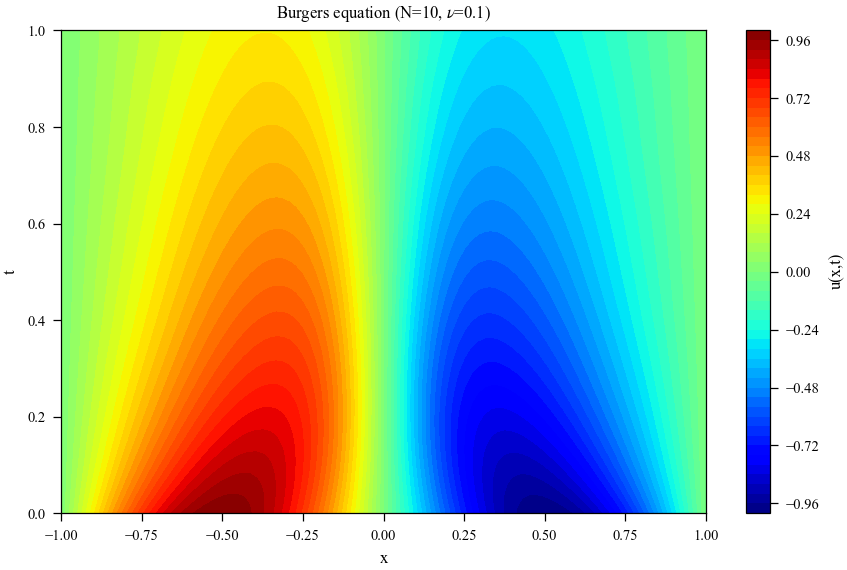

In [11]:
# Visualise Burgers space-time solution
# evaluate_lil_solution takes (basis, coeffs, config) and returns X, T, U
X, T, U = eval_burgers(burg_basis, burg_coeffs, burg_cfg, n_eval=100)

fig, ax = plt.subplots(figsize=(6, 4))
cf = ax.contourf(X, T, U, levels=50, cmap='jet')
plt.colorbar(cf, ax=ax, label='u(x,t)')
ax.set_xlabel('x'); ax.set_ylabel('t')
ax.set_title('Burgers equation (N=10, $\\nu$=0.1)')
plt.tight_layout()
plt.show()

---
## Summary

Comparison of all problems solved in this notebook.

In [12]:
import pandas as pd

summary = pd.DataFrame([
    {'Problem': 'Bratu', 'N': 10, 'DOFs': 100, 'Method': 'LiL-Q',
     'Iters': bratu_summary['total_iterations'],
     'Final Loss': f"{bratu_summary['final_loss']:.2e}",
     'Converged': bratu_summary['converged'],
     'Time (s)': f"{bratu_time:.3f}"},
    {'Problem': 'Kovasznay', 'N': 10, 'DOFs': 300, 'Method': 'LiL-Q',
     'Iters': kov_result['n_outer_iters'],
     'Final Loss': f"{kov_result['pde_mse']:.2e}",
     'Converged': True,
     'Time (s)': f"{kov_time:.3f}"},
    {'Problem': 'Elasticity', 'N': 10, 'DOFs': elast_result['n_params'], 'Method': 'LiL-Q',
     'Iters': 1,
     'Final Loss': f"{elast_result['pde_mse']:.2e}",
     'Converged': True,
     'Time (s)': f"{elast_time:.3f}"},
    {'Problem': 'Burgers', 'N': 10, 'DOFs': 100, 'Method': 'LiL-Q',
     'Iters': burg_summary['total_iterations'],
     'Final Loss': f"{burg_summary['final_loss']:.2e}",
     'Converged': burg_summary['converged'],
     'Time (s)': f"{burg_time:.3f}"},
])

print(summary.to_string(index=False))

   Problem  N  DOFs Method  Iters Final Loss  Converged Time (s)
     Bratu 10   100  LiL-Q      3   2.16e-05       True    0.060
 Kovasznay 10   300  LiL-Q      6   9.06e-16       True    5.556
Elasticity 10   200  LiL-Q      1   3.72e-28       True    0.141
   Burgers 10   100  LiL-Q      3   9.06e-04       True    0.035
